## Problem: When arriving at the Doan Hall stop, the bus is already full from the UH stop. 

### Goals:

- Break down boardings and alightings by stop (UH and Doan) in 30 minute intervals 
- Sample data from approximately 4/1/2026 - 4/14/2026
- 2pm - 4pm timeframe initially, can expand to include 9am, etc.

---

Ultimate goal is to determine if full busses are coming TO Doan FROM UH and pinpoint the timeframe of when the problem is occuring.

---

**NOTES:**
- This is limited by accuracy of the APCs
- No data exists for people 'waiting' for a bus to my knowledge
- This is descriptive of past events and does not necessarily predict future patterns
- I cannot say why busses are overcrowding, only can determine if and when

In [2]:
import sys
import os
import pandas as pd
import numpy as np
import importlib
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Should only have to run 1x here/
# go up one level from notebook folder
sys.path.append(os.path.abspath(".."))

from modules import med_center_dashboard as mcd
importlib.reload(mcd)

# Should contain data from 4/1/2026 to present 4/16/2026
# mcd.busstate_processing(year = "26", month = "04", current_dir = "K:/AP/TTM/Data/WMC_Dashboard/") #stored initial in /analysis_data if needed in future

<module 'modules.med_center_dashboard' from 'k:\\AP\\TTM\\Data\\WMC_Dashboard\\modules\\med_center_dashboard.py'>

In [3]:
import pandas as pd

# ok - busstate data is stored in K:/AP/TTM/Data/WMC_Dashboard/analysis_data
# this contains from 4/1/2026 to present

# apr_df = pd.read_csv("K:/AP/TTM/Data/WMC_Dashboard/analysis_data/2026-APR-busstate.csv")
data_dir = "K:/AP/TTM/Data/WMC_Dashboard/analysis_data/peak_hours"
repo_dir = "K:/AP/TTM/Data/WMC_Dashboard/analysis_data/peak_hours_cleaned"

timeframe_dict = {
    # 'JAN': 2026,
    # 'FEB': 2026,
    'MAR': 2026,
    'APR': 2026
}

df = pd.DataFrame()
for month, year in timeframe_dict.items():
    df = pd.concat([df, mcd.process_mc_busstate(year=year, month=month, current_dir=data_dir, repo_dir=repo_dir)], ignore_index=True)

In [29]:
# Expanding to 3/2/2026 - 4/17/2026 to get more data for peak hours analysis,
# NOTE: Key difference from other file
df = df[(df['DATE'] >= '2026-03-02') & (df['DATE'] <= '2026-04-17')]

In [32]:
# cut down to only doan 37 and UH 401
# should now only have info for UH and Doan stops
ud_doan_mc_df = df[(df['STOP_ID'] == 401) | (df['STOP_ID'] == 37)]

# ud_doan_mc_df

In [4]:
# import visualization libraries
%pip install seaborn matplotlib

import seaborn as sns
import matplotlib.pyplot as plt 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Side by side stop comparison

In [33]:
# cut down sample data to date, time of arrival, stop, boardings, and alightings 
temp = ud_doan_mc_df[['DATE', 'ARRIVAL', 'STOP_ID', 'BOARDINGS', 'ALIGHTINGS']]

# combine date and arrival time to single col
temp['TIME'] = pd.to_datetime(temp['DATE'].astype(str) + ' ' + temp['ARRIVAL'].dt.time.astype(str))
temp.drop(['DATE', 'ARRIVAL'], axis=1, inplace=True)

# break apart timeframes into 30 min intervals - not keeping date specifically
# temp['BUCKET'] = temp['TIME'].dt.floor('30Min').dt.time

# cut down bucket to hr/min, dont need sec
# true 30-min bucket, no date shown
temp['BUCKET'] = temp['TIME'].dt.floor('30min').dt.strftime('%H:%M')

# create a 'net' colum as boardings - alightings
# directional, negative indicates bus 'emptying' passengers, positive indicates bus 'filling' passengers
mc_df = temp.copy()
mc_df['NET'] = mc_df['BOARDINGS'] - mc_df['ALIGHTINGS'] # net indicates PER STOP

# this did NOT work at all
# # sort by stop and time and get a "running load"?
# mc_df.sort_values(['TIME'], inplace=True)
# mc_df['RUNNING_LOAD'] = mc_df.groupby('STOP_ID')['NET'].cumsum()

mc_df.head(20)

,STOP_ID,BOARDINGS,ALIGHTINGS,TIME,BUCKET,NET
2,401,0.0,3.0,2026-03-03 06:05:15,06:00,-3.0
3,37,0.0,3.0,2026-03-03 06:06:00,06:00,-3.0
6,401,0.0,16.0,2026-03-03 06:24:30,06:00,-16.0
7,37,3.0,6.0,2026-03-03 06:25:27,06:00,-3.0
10,401,0.0,33.0,2026-03-03 06:45:39,06:30,-33.0
11,37,2.0,16.0,2026-03-03 06:46:51,06:30,-14.0
14,401,2.0,7.0,2026-03-03 07:06:06,07:00,-5.0
15,37,1.0,5.0,2026-03-03 07:07:09,07:00,-4.0
20,401,0.0,0.0,2026-03-03 07:31:03,07:30,0.0
21,37,8.0,25.0,2026-03-03 07:32:35,07:30,-17.0


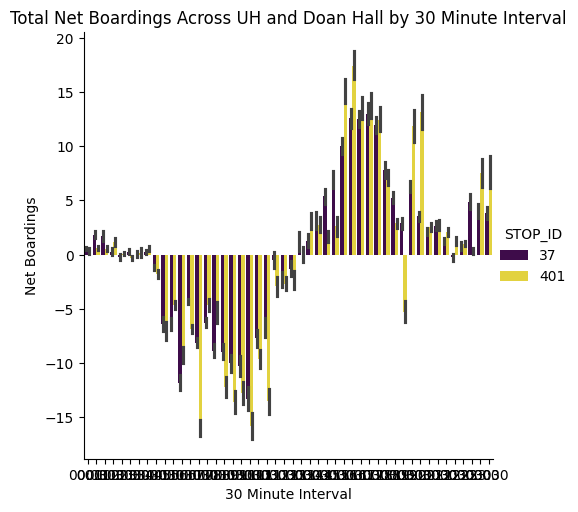

In [34]:
#
mc_df = mc_df.sort_values(by='BUCKET')

plot = sns.catplot(
    data = mc_df,
    x = 'BUCKET',
    y = 'NET',
    hue = 'STOP_ID',
    kind = 'bar',
    palette = "viridis"
)
plot.set(title = "Total Net Boardings Across UH and Doan Hall by 30 Minute Interval")
plot.set_axis_labels("30 Minute Interval", "Net Boardings")
plt.show()

In [35]:
# Summary stats of the dataset I am working with here
mc_df.describe()

,STOP_ID,BOARDINGS,ALIGHTINGS,TIME,NET
count,20376.000000,20376.000000,20376.000000,20376,20376.000000
mean,217.195720,4.953229,4.939880,2026-03-25 08:28:19.486160,0.013349
min,37.000000,0.000000,0.000000,2026-03-02 00:32:24,-41.000000
25%,37.000000,0.000000,0.000000,2026-03-12 14:35:12.500000,-6.000000
50%,37.000000,2.000000,2.000000,2026-03-24 21:34:45,0.000000
75%,401.000000,7.000000,8.000000,2026-04-07 13:43:01.750000,5.000000
max,401.000000,53.000000,42.000000,2026-04-17 23:55:07,52.000000
std,181.995522,7.095127,6.411789,NaN,10.467357


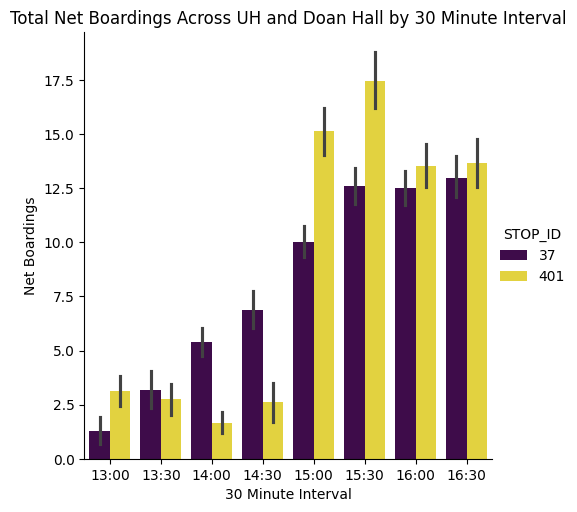

In [37]:
sns.set_palette("viridis_r")

# cut down sample data to doan hall and uh stops separately
# cut down to 1:30pm - 4:30pm for a buffer
mc_df_2_4 = mc_df[(mc_df['TIME'].dt.time > pd.to_datetime('13:00').time()) & (mc_df['TIME'].dt.time <= pd.to_datetime('17:00').time())]
mc_df_2_4 = mc_df_2_4.sort_values(by='TIME')

uh_df = mc_df_2_4[mc_df_2_4['STOP_ID'] == 401]
doan_df = mc_df_2_4[mc_df_2_4['STOP_ID'] == 37]


plot = sns.catplot(
    data = mc_df_2_4,
    x = 'BUCKET',
    y = 'NET',
    hue = 'STOP_ID',
    kind = 'bar',
    palette = "viridis"
)
plot.set(title = "Total Net Boardings Across UH and Doan Hall by 30 Minute Interval")
plot.set_axis_labels("30 Minute Interval", "Net Boardings")
plt.show()

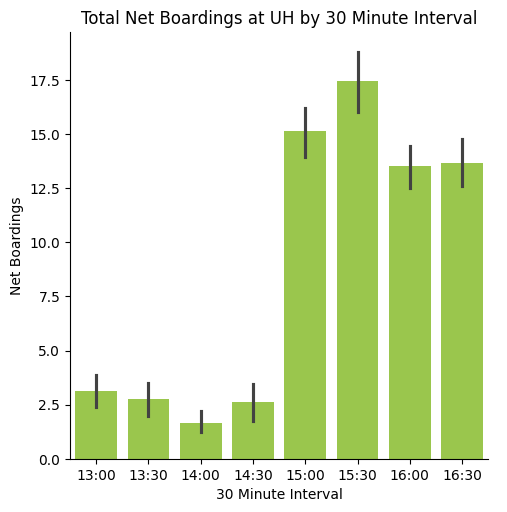

In [39]:
# plot UH individually
plot = sns.catplot(
    data = uh_df,
    x = 'BUCKET',
    y = 'NET',
    kind = 'bar'
)
plot.set(title = "Total Net Boardings at UH by 30 Minute Interval")
plot.set_axis_labels("30 Minute Interval", "Net Boardings")
plt.show()

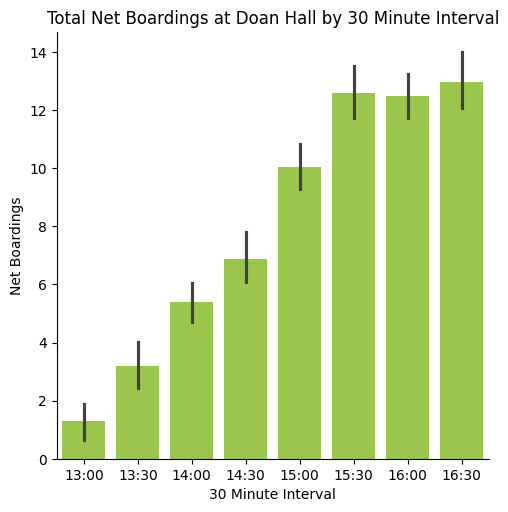

In [40]:
# plot Doan Hall individually
plot = sns.catplot(
    data = doan_df,
    x = 'BUCKET',
    y = 'NET',
    kind = 'bar'
)
plot.set(title = "Total Net Boardings at Doan Hall by 30 Minute Interval")
plot.set_axis_labels("30 Minute Interval", "Net Boardings")
plt.show()

### NOTES:

- There is a sharp increase overall for net boarding at 1500 for UH, meanwhile there is a more gradual increase in net boardings for Doan 
- this COULD indicate a sharp shift change that is present at UH but not Doan?
- Doan hall also has a lower overall net boardings than UH in this timeframe
- Net is POSITIVE - meaning bus is 'filling' throughout this timeframe

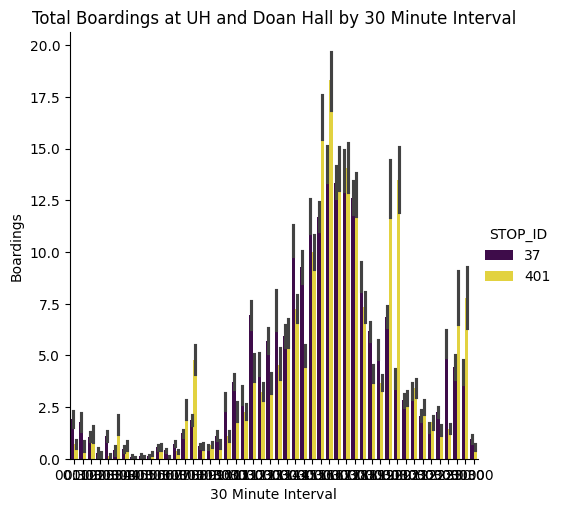

In [41]:
# Break apart boardings for UH and Doan Hall
plot = sns.catplot(
    data = mc_df,
    x = 'BUCKET',
    y = 'BOARDINGS',
    hue = 'STOP_ID',
    kind = 'bar',
    palette = "viridis"
)
plot.set(title = "Total Boardings at UH and Doan Hall by 30 Minute Interval")
plot.set_axis_labels("30 Minute Interval", "Boardings")
plt.show()

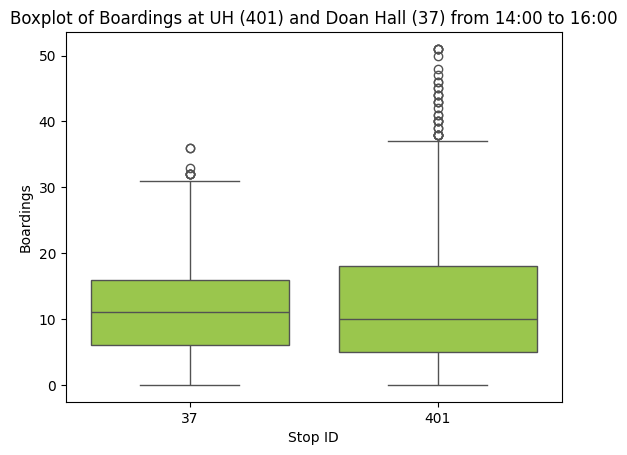

In [44]:
# quick outlier assessment
# cut down exactly to desired timeframe
temp = mc_df[(mc_df['TIME'].dt.time >= pd.to_datetime('14:00').time()) & (mc_df['TIME'].dt.time <= pd.to_datetime('16:00').time())]

sns.boxplot(data=temp, x='STOP_ID', y='BOARDINGS')
plt.title("Boxplot of Boardings at UH (401) and Doan Hall (37) from 14:00 to 16:00")
plt.xlabel("Stop ID")
plt.ylabel("Boardings")
plt.show()

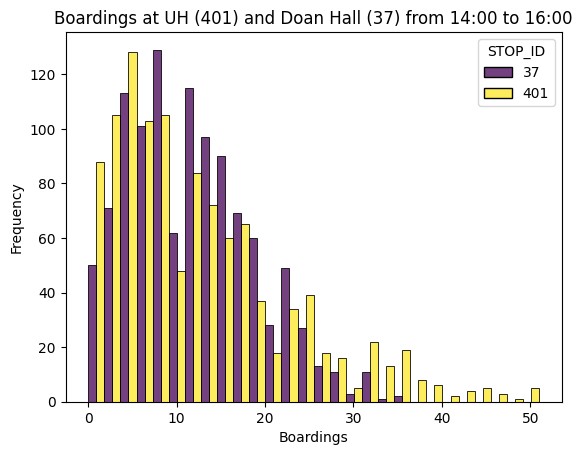

In [14]:
# Generate histogram of boardings at UH and Doan Hall from 14:00 to 16:00
sns.histplot(data=temp, x='BOARDINGS', hue='STOP_ID', multiple='dodge', palette="viridis")
plt.title("Boardings at UH (401) and Doan Hall (37) from 14:00 to 16:00")
plt.xlabel("Boardings")
plt.ylabel("Frequency")
plt.show()

### NOTES:
- 75% of the time both stops are getting approximately 20 or less boardings from 2-4pm
- There are a decent number of outliers at UH stops for boardings that can incrase all the way up to over 50
- Data for UH stop seems very skewed, meanwhile Doan Hall stop seems for normally distributed
- Doan hall could be lower due to busses being fuller when arriving and people deciding to wait to board. 
    - Cannot say for certain this is the case without studying the behavior of those waiting for the bus at Doan hall

In [21]:
# Outlier analysis: compute Q1/Q3/IQR per stop (not globally)
# Determine outlier threshold by stop using Q3 + 1.5*IQR
stop_stats = (
    temp.groupby('STOP_ID')['BOARDINGS']
    .quantile([0.25, 0.75])
    .unstack()
    .rename(columns={0.25: 'q1', 0.75: 'q3'})
)
stop_stats['iqr'] = stop_stats['q3'] - stop_stats['q1']
stop_stats['max_threshold'] = stop_stats['q3'] + 1.5 * stop_stats['iqr']

# Keep these variables for downstream cells
max_threshold_uh = stop_stats.loc[401, 'max_threshold']
max_threshold_doan = stop_stats.loc[37, 'max_threshold']

print('Per-stop thresholds:')
display(stop_stats)
print(f"Max Threshold for UH (401): {max_threshold_uh}")
print(f"Max Threshold for Doan (37): {max_threshold_doan}")

doan_outliers = temp[(temp['STOP_ID'] == 37) & (temp['BOARDINGS'] > max_threshold_doan)]
doan_outliers 

Per-stop thresholds:


,q1,q3,iqr,max_threshold
STOP_ID,,,,
37,6.0,16.0,10.0,31.0
401,5.0,18.0,13.0,37.5


Max Threshold for UH (401): 37.5
Max Threshold for Doan (37): 31.0


,STOP_ID,BOARDINGS,ALIGHTINGS,TIME,BUCKET,NET
27331,37,32.0,17.0,2026-03-02 14:56:55,14:30,15.0
7769,37,32.0,0.0,2026-03-03 15:49:11,15:30,32.0
28265,37,33.0,12.0,2026-03-06 14:57:31,14:30,21.0
1104,37,32.0,0.0,2026-03-11 15:27:07,15:00,32.0
28978,37,36.0,2.0,2026-03-11 15:43:29,15:30,34.0
21677,37,32.0,0.0,2026-03-18 15:40:38,15:30,32.0
2292,37,32.0,0.0,2026-03-25 15:45:12,15:30,32.0
36784,37,36.0,1.0,2026-04-07 15:43:11,15:30,35.0


In [22]:
uh_outliers = temp[(temp['STOP_ID'] == 401) & (temp['BOARDINGS'] > max_threshold_uh)]
uh_outliers

,STOP_ID,BOARDINGS,ALIGHTINGS,TIME,BUCKET,NET
27342,401,51.0,3.0,2026-03-02 15:39:51,15:30,48.0
19882,401,45.0,1.0,2026-03-03 15:31:11,15:30,44.0
12072,401,43.0,3.0,2026-03-03 15:34:49,15:30,40.0
28270,401,40.0,2.0,2026-03-06 15:18:20,15:00,38.0
15490,401,46.0,0.0,2026-03-06 15:34:25,15:30,46.0
82,401,45.0,4.0,2026-03-09 15:35:42,15:30,41.0
24431,401,51.0,2.0,2026-03-11 15:32:57,15:30,49.0
170,401,51.0,0.0,2026-03-11 15:40:20,15:30,51.0
13317,401,38.0,2.0,2026-03-12 15:32:04,15:30,36.0
221,401,51.0,0.0,2026-03-13 15:36:33,15:30,51.0


In [28]:
# Goal - get the context of these total outliers paired with the subsequent Doan Hall boardings
# Goal - get the context of these total outliers paired with the subsequent Doan Hall boardings
outlier_mask = (temp['STOP_ID'] == 401) & (temp['BOARDINGS'] > max_threshold_uh)
subsequent_doan_mask = (temp.index.isin(temp.index[outlier_mask] + 1)) & (temp['STOP_ID'] == 37)

total_outliers = temp[outlier_mask | subsequent_doan_mask].sort_index()
total_outliers.sort_values(by = 'TIME')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
total_outliers

,STOP_ID,BOARDINGS,ALIGHTINGS,TIME,BUCKET,NET
82,401,45.0,4.0,2026-03-09 15:35:42,15:30,41.0
83,37,10.0,0.0,2026-03-09 15:37:46,15:30,10.0
170,401,51.0,0.0,2026-03-11 15:40:20,15:30,51.0
171,37,7.0,3.0,2026-03-11 15:42:21,15:30,4.0
221,401,51.0,0.0,2026-03-13 15:36:33,15:30,51.0
222,37,1.0,1.0,2026-03-13 15:38:53,15:30,0.0
316,401,41.0,0.0,2026-03-19 15:34:22,15:30,41.0
317,37,13.0,3.0,2026-03-19 15:36:20,15:30,10.0
1429,401,46.0,1.0,2026-03-25 15:35:41,15:30,45.0
1430,37,10.0,8.0,2026-03-25 15:39:06,15:30,2.0


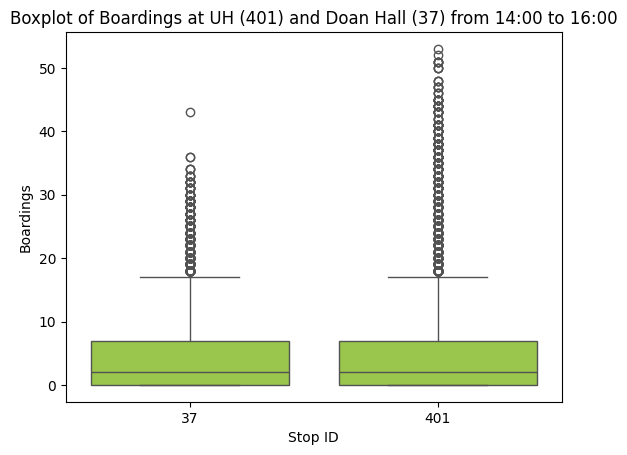

In [46]:
# quick outlier assessment
# full analysis

sns.boxplot(data=mc_df, x='STOP_ID', y='BOARDINGS')
plt.title("Boxplot of Boardings at UH (401) and Doan Hall (37) from 14:00 to 16:00")
plt.xlabel("Stop ID")
plt.ylabel("Boardings")
plt.show()

In [50]:
full_stop_stats = (
    mc_df.groupby('STOP_ID')['BOARDINGS']
    .quantile([0.25, 0.75])
    .unstack()
    .rename(columns={0.25: 'q1', 0.75: 'q3'})
)
full_stop_stats['iqr'] = full_stop_stats['q3'] - full_stop_stats['q1']
full_stop_stats['max_threshold'] = full_stop_stats['q3'] + 1.5 * full_stop_stats['iqr']

# Keep these variables for downstream cells
max_threshold_uh = full_stop_stats.loc[401, 'max_threshold']
max_threshold_doan = full_stop_stats.loc[37, 'max_threshold']

print('Per-stop thresholds:')
display(full_stop_stats)
print(f"Max Threshold for UH (401): {max_threshold_uh}")
print(f"Max Threshold for Doan (37): {max_threshold_doan}")

doan_outliers = temp[(temp['STOP_ID'] == 37) & (temp['BOARDINGS'] > max_threshold_doan)]
print(f'Doan Hall Outliers: {doan_outliers["BUCKET"].value_counts()}')

uh_outliers = temp[(temp['STOP_ID'] == 401) & (temp['BOARDINGS'] > max_threshold_uh)]
print(f'UH Outliers: {uh_outliers["BUCKET"].value_counts()}')

Per-stop thresholds:


,q1,q3,iqr,max_threshold
STOP_ID,,,,
37,0.0,7.0,7.0,17.5
401,0.0,7.0,7.0,17.5


Max Threshold for UH (401): 17.5
Max Threshold for Doan (37): 17.5
Doan Hall Outliers: BUCKET
15:30    93
14:30    63
15:00    54
14:00    31
Name: count, dtype: int64
UH Outliers: BUCKET
15:30    127
15:00    117
14:30     39
14:00      4
Name: count, dtype: int64


**NOTE:** Every outlier is between 2pm and 3:30pm

In [45]:
num_outliers_doan = len(doan_outliers)
num_outliers_uh = len(uh_outliers)

print(f'Total outliers - Doan Hall: {num_outliers_doan}, UH: {num_outliers_uh}')

total_days = 11
print(f'Average outliers per day - Doan Hall: {num_outliers_doan / total_days}, UH: {num_outliers_uh / total_days}')
print(f'Expected outliers per day: {(num_outliers_doan + num_outliers_uh) / total_days}')

Total outliers - Doan Hall: 8, UH: 32
Average outliers per day - Doan Hall: 0.7272727272727273, UH: 2.909090909090909
Expected outliers per day: 3.6363636363636362


Overcrowding of a bus stop (defined as > 32 people boarding at doan or > 38 at UH) appears to occur indiscriminately based on day but occurs at that specific timeframe in the data studied.

Total "overcrowding" events between both stops is 12 in this sample (11 at UH, 1 at Doan).

11 Weekdays in sample size, therefore overcrowding of a bus stop is likely to occur slightly more than once per day at a rate of 1.09